# Quanto vale um apartamento em São Paulo?
## Random Forest, XGBoost e LightGBM — continuação do CP04

**Data Science & Statistical Computing — Checkpoint 5 — FIAP 2026**

**Grupo:** Enzo Augusto (RM562249) · Rafaell Santiago (RM563486) · Gustavo Neres (RM561785) · Sebastian Iriarte (RM563619)

---

## Resumo do projeto

**Problema.** Estimar o preço de venda anunciado de apartamentos em São Paulo a partir das características do imóvel (área, quartos, banheiros, suítes, vagas, condomínio, itens do prédio e localização). É um problema de regressão e continua o que fizemos no CP04, agora com modelos de árvore.

**Base.** *São Paulo Real Estate — Sale / Rent — April 2019* (Kaggle). 6.412 anúncios de venda, 6.240 depois do tratamento.

**Protocolo.** Treino 80% e teste 20%. Dentro do treino, validação cruzada com 5 folds, a mesma para os três modelos e para todas as buscas. Métrica principal: RMSE em reais. O teste só foi usado no final.

**Resultado.**

| Etapa | Modelo | RMSE | MAE | R² |
|---|---|---|---|---|
| Validação cruzada | LightGBM (Optuna) | R\$ 221,1 mil | R\$ 95,5 mil | 0,91 |
| Teste final | LightGBM (Optuna) | R\$ 197,9 mil | R\$ 88,0 mil | 0,93 |

**Onde está cada parte**

1. Problema e base de dados
2. Tratamento dos dados e análise exploratória
3. Variáveis e desenho do experimento
4. Os três modelos
5. Ajuste dos hiperparâmetros: Grid Search e Optuna
6. Escolha do modelo final
7. Teste final e aplicação

---

---

## Bibliotecas

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [2]:
import os
import sys
import json
import subprocess
import warnings
from time import perf_counter

# no Colab, xgboost/lightgbm/optuna podem precisar ser instalados (mesma ideia do ensure_package da aula 20)
for pacote in ["xgboost", "lightgbm", "optuna"]:
    try:
        __import__(pacote)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pacote])

import joblib
from sklearn.base import clone
from IPython.display import display
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import (train_test_split, KFold, cross_validate, cross_val_score,
                                     cross_val_predict, GridSearchCV, learning_curve)
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import optuna

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 42

/usr/local/lib/python3.13/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---

## 1. Problema e base de dados

Este trabalho continua o CP04. Lá usamos regressão linear e polinomial para estimar o preço de apartamentos em São Paulo; aqui usamos a mesma base e o mesmo problema, agora com Random Forest, XGBoost e LightGBM.

**Contexto e problema.** O preço de apartamentos em São Paulo varia muito, mesmo entre imóveis parecidos, e é difícil saber se um valor anunciado está dentro do mercado. Queremos estimar o preço de venda de um apartamento a partir das suas características: área, quartos, banheiros, suítes, vagas, condomínio, itens do prédio e localização. Temos milhares de anúncios com essas informações e o preço, então dá para treinar um modelo supervisionado. No CP04 vimos que a relação entre as variáveis e o preço não é linear, e modelos de árvore lidam melhor com isso.

**Variável-alvo.** $y$ é o preço de venda anunciado, em reais. Como é um valor contínuo, o problema é de regressão. A previsão $\hat{y}$ é o preço esperado para um apartamento com aquelas características. Como a base é de anúncios, $\hat{y}$ representa o preço pedido, e não o valor pelo qual o imóvel foi vendido.

**Base de dados.** *São Paulo Real Estate — Sale / Rent — April 2019*, do Kaggle (https://www.kaggle.com/datasets/argonalyst/sao-paulo-real-estate-sale-rent-april-2019). São anúncios de sites de classificados coletados em abril de 2019. Cada linha é um anúncio. Lemos o CSV por uma cópia pública (a mesma usada no CP04), para o notebook rodar sem download manual.

Lemos a base direto por URL (a mesma cópia usada no CP04), assim o notebook roda em qualquer computador sem precisar baixar arquivo. O código mostra o tamanho da base e quantos anúncios são de venda e quantos são de aluguel.

In [3]:
url = "https://raw.githubusercontent.com/mathdeoliveira/files/master/sao-paulo-properties-april-2019.csv"
imoveis = pd.read_csv(url)

print("Linhas e colunas da base original:", imoveis.shape)
print()
print(imoveis["Negotiation Type"].value_counts())
imoveis.head()

Linhas e colunas da base original: (13640, 16)

Negotiation Type
rent    7228
sale    6412
Name: count, dtype: int64


,Price,Condo,Size,Rooms,Toilets,Suites,Parking,Elevator,Furnished,Swimming Pool,New,District,Negotiation Type,Property Type,Latitude,Longitude
0,930,220,47,2,2,1,1,0,0,0,0,Artur Alvim/São Paulo,rent,apartment,-23.543138,-46.479486
1,1000,148,45,2,2,1,1,0,0,0,0,Artur Alvim/São Paulo,rent,apartment,-23.550239,-46.480718
2,1000,100,48,2,2,1,1,0,0,0,0,Artur Alvim/São Paulo,rent,apartment,-23.542818,-46.485665
3,1000,200,48,2,2,1,1,0,0,0,0,Artur Alvim/São Paulo,rent,apartment,-23.547171,-46.483014
4,1300,410,55,2,2,1,1,1,0,0,0,Artur Alvim/São Paulo,rent,apartment,-23.525025,-46.482436


Dicionário de dados:

| Coluna | Nome no projeto | Tipo | Unidade | Descrição |
|---|---|---|---|---|
| Price | preco | contínua | R\$ | Preço anunciado (alvo) |
| Condo | condominio | contínua | R\$/mês | Condomínio mensal (0 quando não informado) |
| Size | area_m2 | contínua | m² | Área privativa |
| Rooms | quartos | discreta | unidades | Quartos |
| Toilets | banheiros | discreta | unidades | Banheiros |
| Suites | suites | discreta | unidades | Suítes |
| Parking | vagas | discreta | unidades | Vagas de garagem |
| Elevator | elevador | 0/1 | — | Prédio com elevador |
| Furnished | mobiliado | 0/1 | — | Imóvel mobiliado |
| Swimming Pool | piscina | 0/1 | — | Condomínio com piscina |
| New | novo | 0/1 | — | Imóvel novo |
| District | distrito | categórica | — | Distrito de São Paulo |
| Negotiation Type | — | categórica | — | Venda (sale) ou aluguel (rent) |
| Property Type | — | categórica | — | Tipo de imóvel |
| Latitude, Longitude | latitude, longitude | contínuas | graus | Localização do anúncio |

Antes de tratar os dados, olhamos como o preço de venda se distribui, na escala normal e na escala log.

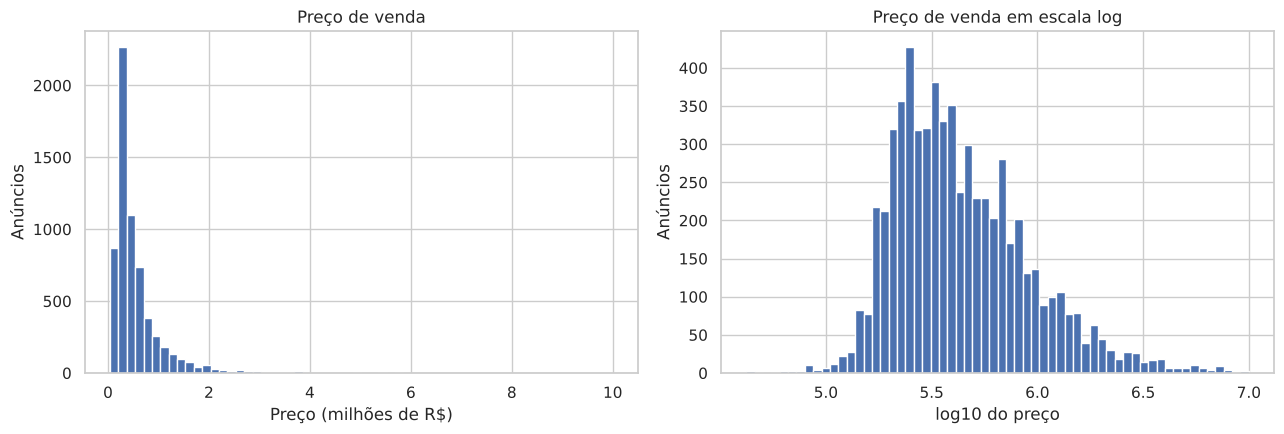

count        6412.0
mean       608624.0
std        740452.0
min         42000.0
25%        250000.0
50%        380000.0
75%        679000.0
max      10000000.0
Name: Price, dtype: float64
Assimetria do preço: 5.1
Assimetria do log do preço: 0.84


In [4]:
# distribuição do preço de venda
venda_bruta = imoveis[imoveis["Negotiation Type"] == "sale"]

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].hist(venda_bruta["Price"] / 1e6, bins=60)
ax[0].set_title("Preço de venda")
ax[0].set_xlabel("Preço (milhões de R$)")
ax[0].set_ylabel("Anúncios")
ax[1].hist(np.log10(venda_bruta["Price"]), bins=60)
ax[1].set_title("Preço de venda em escala log")
ax[1].set_xlabel("log10 do preço")
ax[1].set_ylabel("Anúncios")
plt.tight_layout()
plt.show()

print(venda_bruta["Price"].describe().round(0))
print("Assimetria do preço:", round(venda_bruta["Price"].skew(), 2))
print("Assimetria do log do preço:", round(np.log(venda_bruta["Price"]).skew(), 2))

A maioria dos anúncios fica abaixo de R\$ 1 milhão (mediana de R\$ 380 mil), mas alguns chegam a R\$ 10 milhões, o que puxa a média para R\$ 609 mil. A assimetria é de 5,1. Em escala log a distribuição fica bem mais equilibrada (assimetria de 0,84).

Por isso vamos treinar os modelos com o log do preço. Sem o log, os poucos imóveis de R\$ 5 a 10 milhões dominariam o erro durante o treino, e o modelo se esforçaria para acertar esses casos, piorando nos imóveis comuns. Com o log, o erro passa a ser olhado em proporção ao valor do imóvel. Isso não deixa as métricas artificialmente melhores: o modelo aprende em log, mas a previsão é convertida de volta para reais antes de calcular qualquer métrica. E essa assimetria não é um defeito da base; preço de imóvel é assim em qualquer lugar, e o House Prices das aulas tem o mesmo comportamento.

**Critério de sucesso.** A métrica principal é o RMSE, em reais. Escolhemos o RMSE porque ele mostra o tamanho do erro na mesma unidade do preço e pesa mais os erros grandes, que são os mais graves quando se fala de preço de imóvel.

Usamos também o MAE, que é a média simples do erro em reais e o número mais fácil de explicar ("o modelo erra, em média, tantos reais"). Como o RMSE eleva os erros ao quadrado antes da média, ele sempre fica maior que o MAE, e quanto maior a distância entre os dois, mais existem erros grandes isolados. O R² mostra quanto da variação dos preços o modelo explica, mas não diz de quanto é o erro, por isso não é a métrica principal. Todos os modelos, as buscas e a escolha final usam o RMSE.

---

## 2. Tratamento dos dados e análise exploratória

Como no CP04, ficamos só com os anúncios de venda; os de aluguel estão em outra escala (R\$ por mês) e são outro mercado. Desta vez olhamos a base com mais cuidado antes de tratar, porque no CP04 deixamos passar alguns problemas.

O código abaixo renomeia as colunas para os mesmos nomes do CP04, tira o "/São Paulo" do nome do distrito, remove as duas colunas que viraram constantes (tipo de negociação e tipo de imóvel) e conta os problemas mais comuns: valores vazios, linhas repetidas, zeros que não fazem sentido e combinações impossíveis.

In [5]:
venda = imoveis[imoveis["Negotiation Type"] == "sale"].copy()
venda = venda.rename(columns={
    "Price": "preco", "Condo": "condominio", "Size": "area_m2", "Rooms": "quartos",
    "Toilets": "banheiros", "Suites": "suites", "Parking": "vagas", "Elevator": "elevador",
    "Furnished": "mobiliado", "Swimming Pool": "piscina", "New": "novo", "District": "distrito",
    "Latitude": "latitude", "Longitude": "longitude",
})
venda["distrito"] = venda["distrito"].str.replace("/São Paulo", "", regex=False)
venda = venda.drop(columns=["Negotiation Type", "Property Type"])  # só venda e só apartamento

print("Anúncios de venda:", venda.shape)
print("Valores ausentes:", venda.isna().sum().sum())
print("Linhas duplicadas:", venda.duplicated().sum())
print("Condomínio igual a 0:", (venda["condominio"] == 0).sum())
print("Latitude ou longitude igual a 0:", ((venda["latitude"] == 0) | (venda["longitude"] == 0)).sum())
print("Suítes maior que quartos:", (venda["suites"] > venda["quartos"]).sum())
print("Preço ou área menor ou igual a 0:", ((venda["preco"] <= 0) | (venda["area_m2"] <= 0)).sum())
print(venda.dtypes)

Anúncios de venda: (6412, 14)
Valores ausentes: 0
Linhas duplicadas: 110
Condomínio igual a 0: 1337
Latitude ou longitude igual a 0: 398
Suítes maior que quartos: 2
Preço ou área menor ou igual a 0: 0
preco           int64
condominio      int64
area_m2         int64
quartos         int64
banheiros       int64
suites          int64
vagas           int64
elevador        int64
mobiliado       int64
piscina         int64
novo            int64
distrito          str
latitude      float64
longitude     float64
dtype: object


Também conferimos se as coordenadas caem dentro da cidade de São Paulo, usando um retângulo aproximado em volta da cidade.

In [6]:
# coordenadas preenchidas, mas fora da cidade de São Paulo
dentro_sp = venda["latitude"].between(-24, -23.3) & venda["longitude"].between(-47, -46.3)
com_coord = (venda["latitude"] != 0) & (venda["longitude"] != 0)
print("Anúncios com coordenada fora da cidade:", (com_coord & ~dentro_sp).sum())
print(venda[com_coord & ~dentro_sp]["distrito"].value_counts().head())
print()
print("Coordenada mediana do distrito Medeiros:")
print(venda[(venda["distrito"] == "Medeiros") & com_coord][["latitude", "longitude"]].median())

Anúncios com coordenada fora da cidade: 73
distrito
Medeiros        32
Barra Funda      4
Aricanduva       4
Bela Vista       4
Cidade Dutra     3
Name: count, dtype: int64

Coordenada mediana do distrito Medeiros:
latitude    -23.183597
longitude   -46.985039
dtype: float64


A base não tem nenhum valor vazio, mas tem problemas escondidos:

- 110 anúncios repetidos, iguais em todas as colunas, inclusive nas coordenadas.
- 1.337 anúncios com condomínio igual a 0. Apartamento não tem condomínio zero, então isso quer dizer que a informação não foi preenchida.
- 398 anúncios com latitude ou longitude igual a 0, e 73 com coordenadas fora da cidade.
- 32 desses 73 são do "distrito" Medeiros, cuja coordenada mediana (-23,18; -46,99) fica na região de Jundiaí. Medeiros não é distrito de São Paulo.
- 2 anúncios com mais suítes do que quartos.

No CP04 só tínhamos tratado as duplicatas e o condomínio zerado.

Com o diagnóstico feito, tratamos os problemas um de cada vez, mostrando quantas linhas cada passo removeu:

- **Anúncios repetidos:** como todas as colunas são iguais, inclusive as coordenadas e o condomínio, é o mesmo anúncio publicado mais de uma vez.
- **Medeiros:** as coordenadas ficam na região de Jundiaí e Medeiros não é distrito de São Paulo, então esses anúncios estão fora do nosso problema.
- **Mais suítes do que quartos:** é impossível, então é erro de cadastro.

In [7]:
linhas_antes = len(venda)

# 1) anúncios repetidos (todas as colunas iguais, inclusive coordenadas)
venda = venda.drop_duplicates()
print("Duplicatas removidas:", linhas_antes - len(venda))

# 2) Medeiros não é distrito de São Paulo (coordenadas na região de Jundiaí)
antes = len(venda)
venda = venda[venda["distrito"] != "Medeiros"]
print("Anúncios de Medeiros removidos:", antes - len(venda))

# 3) mais suítes do que quartos é erro de cadastro
antes = len(venda)
venda = venda[venda["suites"] <= venda["quartos"]]
print("Anúncios com suítes > quartos removidos:", antes - len(venda))

Duplicatas removidas: 110
Anúncios de Medeiros removidos: 49
Anúncios com suítes > quartos removidos: 2


O condomínio igual a 0 e as coordenadas zeradas ou fora da cidade não são valores reais; são informações que faltaram no anúncio. Em vez de apagar essas linhas, transformamos esses valores em vazios (NaN). O condomínio falta em cerca de 20% dos anúncios, e apagar todos eles jogaria fora muita informação boa das outras colunas. Os vazios são preenchidos depois, dentro do pipeline. Colocamos essa regra em uma função (`limpar_imovel`) porque o app do Streamlit precisa aplicar exatamente a mesma regra.

In [8]:
# 4) valores "zerados" que na verdade estão faltando viram NaN
# (a mesma regra é aplicada no app do Streamlit)
def limpar_imovel(df):
    df = df.copy()
    df["condominio"] = df["condominio"].replace(0, np.nan)
    fora_sp = ~(df["latitude"].between(-24, -23.3) & df["longitude"].between(-47, -46.3))
    df.loc[fora_sp, ["latitude", "longitude"]] = np.nan
    return df

venda = limpar_imovel(venda)
print("Condomínio sem informação:", venda["condominio"].isna().sum())
print("Coordenadas sem informação:", venda["latitude"].isna().sum())

Condomínio sem informação: 1280
Coordenadas sem informação: 428


Por último, procuramos preços incoerentes. Calculamos o preço por m² de cada anúncio e comparamos com a mediana do próprio distrito. O limite de um terço ou três vezes a mediana é largo de propósito, para pegar só casos absurdos, e conferimos cada anúncio encontrado antes de remover.

In [9]:
# 5) preços muito fora do padrão do próprio distrito (preço por m²)
preco_m2 = venda["preco"] / venda["area_m2"]
razao = preco_m2 / preco_m2.groupby(venda["distrito"]).transform("median")
suspeitos = venda[(razao < 1/3) | (razao > 3)]

tabela = suspeitos[["preco", "area_m2", "quartos", "vagas", "distrito"]].copy()
tabela["preco_m2"] = preco_m2[suspeitos.index].round(0)
tabela["vezes_a_mediana"] = razao[suspeitos.index].round(2)
tabela.sort_values("vezes_a_mediana")

,preco,area_m2,quartos,vagas,distrito,preco_m2,vezes_a_mediana
8487,42000,48,1,1,República,875.0,0.13
11377,68000,90,3,2,Aricanduva,756.0,0.16
13141,415000,335,1,1,Tatuapé,1239.0,0.17
13261,136600,98,2,1,Vila Jacuí,1394.0,0.30
6421,45000,40,2,1,Lajeado,1125.0,0.32
7975,100000,55,2,1,Pirituba,1818.0,0.33
11754,98815,51,2,1,Socorro,1938.0,0.33
7519,98815,51,2,1,Socorro,1938.0,0.33
5025,915000,30,3,2,Mooca,30500.0,4.18
11578,3050003,66,3,1,Vila Prudente,46212.0,7.86


Esses 10 anúncios têm preço por m² menor que um terço ou maior que três vezes o normal do distrito. Olhando um por um, parecem erros de digitação: 48 m² na República por R\$ 42 mil, 335 m² com 1 quarto no Tatuapé por R\$ 415 mil, 30 m² com 3 quartos na Mooca e 66 m² em Vila Prudente por R\$ 3.050.003. Os dois de Socorro são o mesmo anúncio repetido. Como são poucos e não representam o mercado, removemos.

Removemos esses 10 anúncios e conferimos de novo as duplicatas e os vazios da base final.

In [10]:
venda = venda.drop(index=suspeitos.index)
venda = venda.drop_duplicates().reset_index(drop=True)  # confere de novo depois da limpeza

print("Base original de venda:", venda_bruta.shape)
print("Base tratada:", venda.shape)
print("Duplicatas:", venda.duplicated().sum())
print("Ausentes por coluna:")
print(venda.isna().sum()[venda.isna().sum() > 0])

Base original de venda: (6412, 16)
Base tratada: (6240, 14)
Duplicatas: 0
Ausentes por coluna:
condominio    1275
latitude       423
longitude      423
dtype: int64


Os imóveis caros, que chegam a R\$ 10 milhões, ficaram na base. Eles não são erros: têm área, vagas e bairro compatíveis com o preço. Tirar esses imóveis só para melhorar a métrica não seria correto, e o modelo deixaria de saber prever imóveis caros.

O preço por m² foi usado só para achar os erros acima. Ele seria uma variável muito forte, mas é calculado com o próprio preço, que é o que queremos prever; colocá-lo no modelo seria vazamento de dados.

Com a base tratada, fizemos três gráficos para entender como as características se relacionam com o preço. O primeiro compara área e preço. Os dois eixos estão em escala log porque os preços vão de menos de R\$ 100 mil a R\$ 10 milhões; em escala normal, os imóveis comuns ficariam amontoados em um canto.

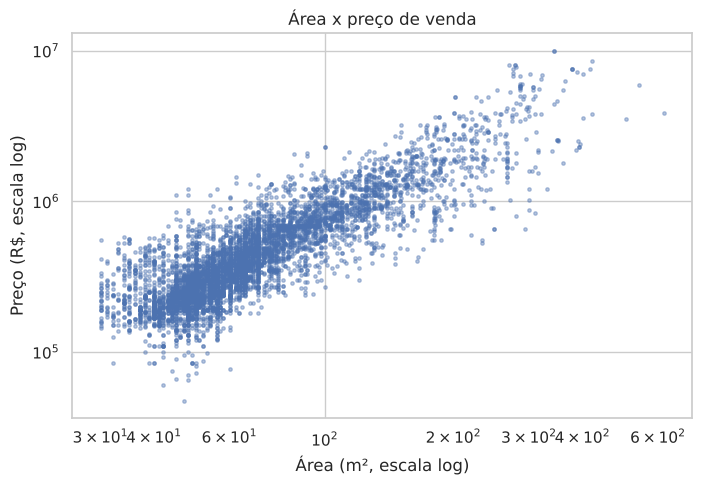

In [11]:
# gráfico: área x preço
plt.figure(figsize=(8, 5))
plt.scatter(venda["area_m2"], venda["preco"], s=6, alpha=0.4)
plt.xscale("log")
plt.yscale("log")
plt.title("Área x preço de venda")
plt.xlabel("Área (m², escala log)")
plt.ylabel("Preço (R$, escala log)")
plt.show()

Quanto maior a área, maior o preço, e a relação é forte (correlação de 0,84). Mas para uma mesma área o preço ainda varia muito, e boa parte dessa diferença vem da localização.

O segundo gráfico mostra cada anúncio no mapa, colorido pelo preço por m².

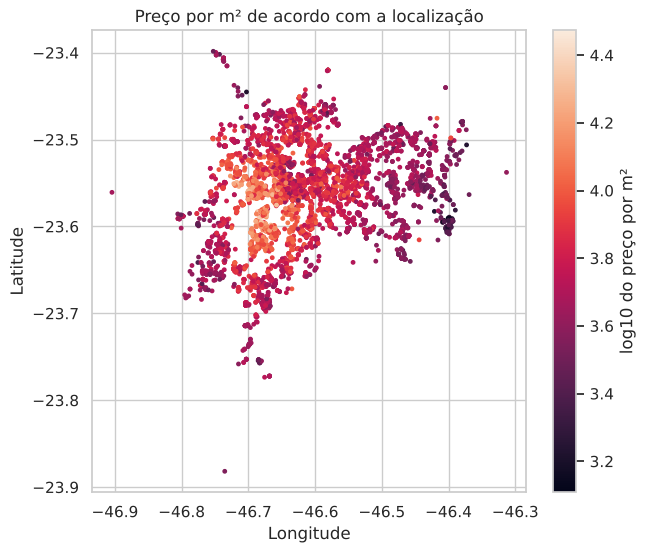

In [12]:
# gráfico: preço por m² no mapa
geo = venda.dropna(subset=["latitude", "longitude"])
plt.figure(figsize=(7, 6))
pontos = plt.scatter(geo["longitude"], geo["latitude"], c=np.log10(geo["preco"] / geo["area_m2"]), s=6)
plt.colorbar(pontos, label="log10 do preço por m²")
plt.title("Preço por m² de acordo com a localização")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

O preço por m² é mais alto na região sudoeste do centro e cai em direção às bordas da cidade, principalmente na zona leste. Como essa relação não é uma reta, latitude e longitude funcionam melhor em modelos de árvore do que na regressão linear do CP04, onde não usamos essas colunas.

Por isso usamos as coordenadas além do distrito: o distrito é uma informação mais grosseira, alguns distritos têm poucos anúncios, e as coordenadas mostram a posição exata do imóvel.

O terceiro gráfico mostra a correlação entre as variáveis numéricas. Usamos a correlação de Spearman porque várias variáveis são contagens (quartos, vagas) e o preço é muito assimétrico; ela mede se uma variável cresce junto com a outra sem exigir que a relação seja uma reta, e sofre menos com valores extremos.

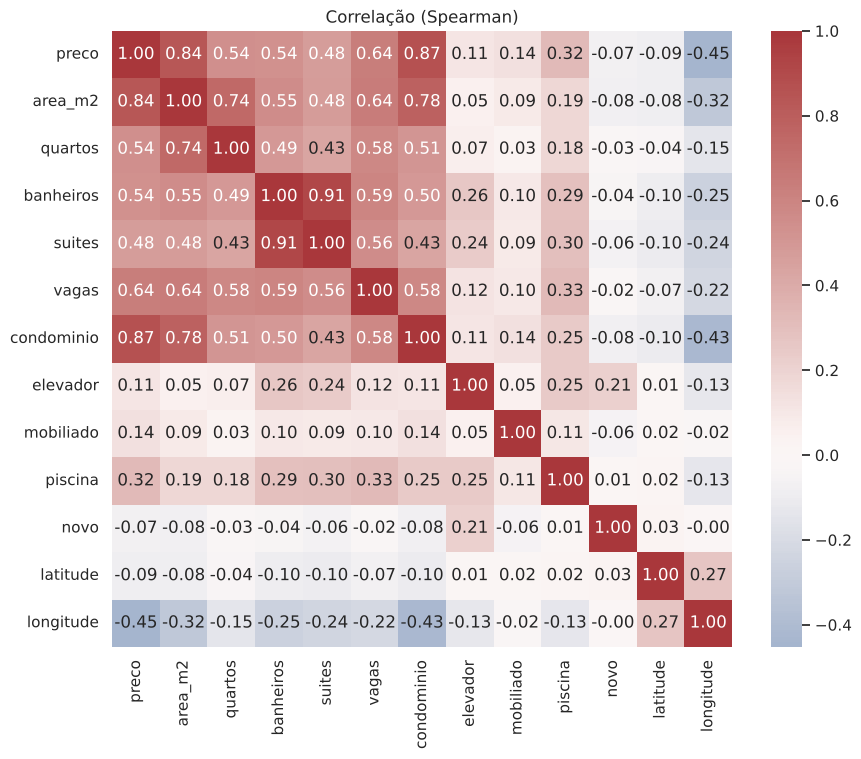

In [13]:
# gráfico: correlação entre as variáveis numéricas
numericas = ["preco", "area_m2", "quartos", "banheiros", "suites", "vagas", "condominio",
             "elevador", "mobiliado", "piscina", "novo", "latitude", "longitude"]
plt.figure(figsize=(10, 8))
sns.heatmap(venda[numericas].corr(method="spearman"), annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Correlação (Spearman)")
plt.show()

O preço tem correlação alta com o condomínio (0,87) e com a área (0,84), e média com vagas, quartos e banheiros. Essas variáveis também são muito correlacionadas entre si (banheiros e suítes, por exemplo, têm 0,91). No CP04 isso deixou os coeficientes instáveis. Nos modelos de árvore não é um problema, porque eles escolhem uma variável por vez em cada divisão; o único efeito é que a importância fica dividida entre variáveis parecidas.

Algumas etapas ficam para dentro do pipeline, porque precisam ser calculadas só com os dados de treino: preencher condomínio e coordenadas que faltam com a mediana e transformar o distrito em colunas 0/1.

---

## 3. Variáveis e desenho do experimento

$X$ tem todas as características do imóvel e $y$ é o preço. Tiramos do modelo o preço por m² (vazamento, porque é calculado com o preço) e as colunas de tipo de negociação e de imóvel, que viraram constantes. O condomínio fica: ele tem relação com o padrão do imóvel, assim como a área, mas não é calculado a partir do preço e aparece no anúncio, então está disponível na hora de prever.

No CP04 as variáveis parecidas entre si (área, quartos, banheiros) deixaram os coeficientes instáveis. Modelos de árvore não têm coeficientes, então podemos manter todas.

Separamos 80% para treino e 20% para teste, com `random_state=42` para a divisão ser sempre a mesma. Como a validação é feita com validação cruzada dentro do treino, não precisamos separar mais um pedaço para validação: sobram cerca de 5 mil anúncios para treinar e 1.250 para o teste final.

Usamos validação cruzada com 5 folds em vez de um único conjunto de validação, como foi feito nas aulas 18 a 20; a própria aula 20 comenta que a validação cruzada dá uma estimativa mais estável quando a base não é muito grande. Assim cada anúncio do treino serve de validação uma vez e temos a média e o desvio do erro, e a comparação entre modelos depende menos da sorte de quais anúncios caíram na validação. O mesmo `KFold` é usado em todos os modelos e buscas, então todos são avaliados nas mesmas partes da base. O teste só é usado na seção 7.

Métrica principal: RMSE. Auxiliares: MAE e R². O scikit-learn devolve os erros com sinal negativo (`neg_root_mean_squared_error`), por isso trocamos o sinal nas tabelas.

In [14]:
colunas_numericas = ["area_m2", "quartos", "banheiros", "suites", "vagas", "condominio",
                     "elevador", "mobiliado", "piscina", "novo", "latitude", "longitude"]
colunas_x = colunas_numericas + ["distrito"]

X = venda[colunas_x]
y = venda["preco"]

X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=SEED)
cv = KFold(n_splits=5, shuffle=True, random_state=SEED)

print("Treino:", X_treino.shape, "| Teste:", X_teste.shape)

Treino: (4992, 13) | Teste: (1248, 13)


O pipeline tem três partes. As colunas numéricas com valor vazio recebem a mediana do treino. O distrito vira colunas 0/1; distritos com menos de 40 anúncios no treino são juntados em um grupo só (`min_frequency=40`), porque sozinhos gerariam colunas quase vazias, e a latitude e a longitude continuam mostrando onde esses imóveis ficam. Por último, o modelo aprende o log do preço e a previsão volta para reais, pelo motivo que vimos na seção 1.

Essas etapas ficam dentro do pipeline para evitar vazamento: se a mediana fosse calculada com a base inteira, os dados de teste influenciariam o treino. Dentro do pipeline, a mediana e as colunas de distrito são calculadas só com a parte de treino de cada fold.

A função `avaliar` faz a validação cruzada de um modelo e devolve o erro no treino, o erro na validação (média e desvio entre os folds), o MAE, o R² e o tempo. Ela é usada em todo o notebook.

In [15]:
def montar_pipeline(modelo):
    preparo = ColumnTransformer([
        # números: valor faltando recebe a mediana do treino (igual ao preprocessador das aulas 18 a 20)
        ("num", SimpleImputer(strategy="median"), colunas_numericas),
        # distrito: vira colunas 0/1; distritos com menos de 40 anúncios no treino vão para um grupo "outros",
        # e um distrito que não apareceu no treino também cai nesse grupo em vez de dar erro
        ("cat", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=40, sparse_output=False), ["distrito"]),
    ])
    pipe = Pipeline([("preparo", preparo), ("modelo", modelo)])
    # o modelo aprende log(preço); na hora de prever, o exp devolve o valor em reais
    return TransformedTargetRegressor(regressor=pipe, func=np.log, inverse_func=np.exp)


def avaliar(nome, modelo):
    t0 = perf_counter()
    res = cross_validate(montar_pipeline(modelo), X_treino, y_treino, cv=cv, return_train_score=True,
                         scoring=["neg_root_mean_squared_error", "neg_mean_absolute_error", "r2"])
    return {
        "Modelo": nome,
        "RMSE_treino": -res["train_neg_root_mean_squared_error"].mean(),
        "RMSE_CV": -res["test_neg_root_mean_squared_error"].mean(),
        "RMSE_CV_dp": res["test_neg_root_mean_squared_error"].std(),
        "MAE_CV": -res["test_neg_mean_absolute_error"].mean(),
        "R2_CV": res["test_r2"].mean(),
        "Tempo_s": perf_counter() - t0,
    }

---

## 4. Os três modelos

**Random Forest.** Treina muitas árvores de decisão independentes. Cada árvore usa uma amostra sorteada dos anúncios e, em cada divisão, olha só uma parte das variáveis (no nosso caso, 60%). A previsão final é a média das árvores. Como cada árvore erra de um jeito, na média os erros se compensam.

**XGBoost.** Também usa muitas árvores, mas treinadas uma depois da outra: cada árvore nova tenta corrigir o erro que as anteriores ainda cometem. A taxa de aprendizado (`learning_rate`) controla o quanto cada árvore corrige, e a profundidade (`max_depth`) controla o quanto cada árvore pode ser complexa.

**LightGBM.** Também é boosting, como o XGBoost, mas cresce as árvores de outro jeito: em vez de crescer nível por nível, ele sempre divide a folha que mais reduz o erro, e agrupa os valores das variáveis em faixas (histogramas), o que pode deixar o treino mais rápido em bases grandes. Na nossa base, que é pequena, isso não apareceu: no baseline o XGBoost foi um pouco mais rápido que o LightGBM. O tamanho de cada árvore é controlado pelo número de folhas (`num_leaves`).

**Como aplicamos na nossa base.** Os três modelos passam exatamente pelo mesmo pipeline: mediana nos valores faltando, distrito em colunas 0/1 e treino com o log do preço. Também usam os mesmos 5 folds e a mesma métrica (RMSE). Assim, a diferença nos resultados vem do algoritmo, e não da preparação dos dados. Começamos com hiperparâmetros baseados nos das aulas 18 a 20 (no Random Forest, 200 árvores e `min_samples_leaf=2`; no XGBoost e no LightGBM, `subsample` e `colsample_bytree` de 0,85 e `num_leaves=31`), sem nenhum ajuste; o ajuste vem na seção 5.

**Por que não usamos early stopping.** Nas aulas, o XGBoost e o LightGBM param de criar árvores quando o erro no conjunto de validação para de cair. Aqui não existe um conjunto de validação fixo, porque usamos validação cruzada: cada fold tem uma validação diferente. Por isso tratamos o número de árvores como um hiperparâmetro comum, que entra no Grid Search e no Optuna. Sem early stopping, começamos com menos árvores do que nas aulas (500 em vez de 900 a 1.200) e uma taxa de aprendizado um pouco maior (0,05 em vez de 0,03), para o modelo inicial não ficar com árvores demais.

O código abaixo cria os três modelos iniciais e avalia cada um com a validação cruzada.

In [16]:
rf_base = RandomForestRegressor(n_estimators=200, max_features=0.6, min_samples_leaf=2, random_state=SEED, n_jobs=-1)
xgb_base = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=5, subsample=0.85,
                        colsample_bytree=0.85, random_state=SEED, n_jobs=-1)
lgbm_base = LGBMRegressor(n_estimators=500, learning_rate=0.05, num_leaves=31, min_child_samples=20,
                          subsample=0.85, subsample_freq=1, colsample_bytree=0.85,
                          random_state=SEED, n_jobs=-1, verbose=-1)

baselines = pd.DataFrame([
    avaliar("Random Forest", rf_base),
    avaliar("XGBoost", xgb_base),
    avaliar("LightGBM", lgbm_base),
])
baselines.round(3)

,Modelo,RMSE_treino,RMSE_CV,RMSE_CV_dp,MAE_CV,R2_CV,Tempo_s
0,Random Forest,132543.883,248273.052,32248.092,105205.778,0.887,8.693
1,XGBoost,101998.391,233164.797,24843.347,98503.678,0.900,3.031
2,LightGBM,106277.657,224897.622,22037.790,96960.325,0.908,5.153


O gráfico compara o erro no treino e na validação de cada modelo (a barra de erro é o desvio entre os folds) e o tempo gasto na validação cruzada.

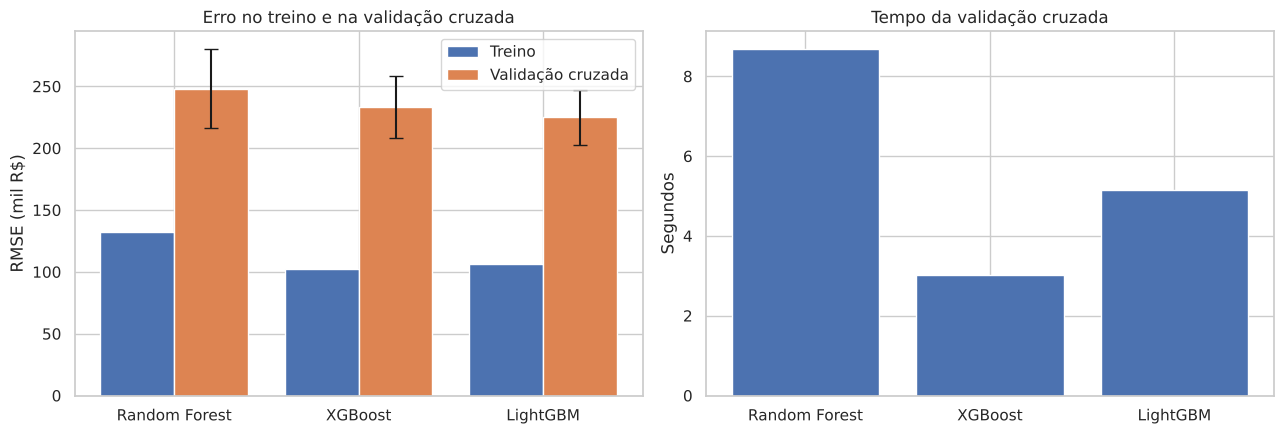

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
pos = np.arange(3)
ax[0].bar(pos - 0.2, baselines["RMSE_treino"] / 1000, 0.4, label="Treino")
ax[0].bar(pos + 0.2, baselines["RMSE_CV"] / 1000, 0.4, yerr=baselines["RMSE_CV_dp"] / 1000, capsize=5, label="Validação cruzada")
ax[0].set_xticks(pos, baselines["Modelo"])
ax[0].set_ylabel("RMSE (mil R$)")
ax[0].set_title("Erro no treino e na validação cruzada")
ax[0].legend()
ax[1].bar(baselines["Modelo"], baselines["Tempo_s"])
ax[1].set_ylabel("Segundos")
ax[1].set_title("Tempo da validação cruzada")
plt.tight_layout()
plt.show()

O LightGBM teve o menor erro de validação (RMSE de R\$ 224,9 mil), seguido do XGBoost (R\$ 233,2 mil) e do Random Forest (R\$ 248,3 mil). A diferença entre LightGBM e XGBoost é menor que o desvio entre os folds (cerca de R\$ 22 mil), então nessa etapa os dois estão praticamente empatados. O Random Forest ficou atrás e foi o mais lento.

Isso faz sentido pelo jeito como os modelos funcionam: no Random Forest as árvores são independentes e o resultado é a média delas, enquanto no XGBoost e no LightGBM cada árvore corrige o erro das anteriores e aproveita melhor os detalhes dos dados.

Nos três modelos o erro no treino é mais ou menos metade do erro na validação. Existe algum overfitting, o que é normal em modelos de árvore; o que importa para comparar é o erro na validação e se ele é estável entre os folds, e o ajuste da seção 5 serve para tentar controlar isso. Não há underfitting: o R² de validação ficou perto de 0,9 nos três.

---

## 5. Ajuste dos hiperparâmetros: Grid Search e Optuna

**Grid Search.** O Grid Search testa todas as combinações de uma lista de valores. Em cada modelo testamos um valor menor e um maior para o número de árvores e para os parâmetros que controlam a complexidade (profundidade, tamanho mínimo das folhas, número de folhas); no XGBoost e no LightGBM, também a taxa de aprendizado.

As grades são pequenas porque cada combinação é treinada 5 vezes, uma por fold. A grade do Random Forest, com 16 combinações, já são 80 treinos, e cada valor a mais em um parâmetro multiplica esse número.

In [18]:
# o nome dos parâmetros segue o caminho até o modelo dentro do pipeline:
# regressor (TransformedTargetRegressor) -> modelo (etapa do Pipeline) -> parâmetro
grades = {
    "Random Forest": (rf_base, {
        "regressor__modelo__n_estimators": [100, 200],
        "regressor__modelo__max_depth": [None, 16],
        "regressor__modelo__min_samples_leaf": [1, 3],
        "regressor__modelo__max_features": [0.4, 0.8],
    }),
    "XGBoost": (xgb_base, {
        "regressor__modelo__n_estimators": [400, 900],
        "regressor__modelo__learning_rate": [0.03, 0.08],
        "regressor__modelo__max_depth": [4, 7],
        "regressor__modelo__min_child_weight": [1, 5],
    }),
    "LightGBM": (lgbm_base, {
        "regressor__modelo__n_estimators": [400, 900],
        "regressor__modelo__learning_rate": [0.03, 0.08],
        "regressor__modelo__num_leaves": [15, 31, 63],
        "regressor__modelo__min_child_samples": [10, 30],
    }),
}

buscas_grid = {}
linhas = []
for nome, (modelo, grade) in grades.items():
    busca = GridSearchCV(montar_pipeline(modelo), grade, cv=cv, scoring="neg_root_mean_squared_error",
                         return_train_score=True, refit=False)
    t0 = perf_counter()
    busca.fit(X_treino, y_treino)
    tempo = perf_counter() - t0
    buscas_grid[nome] = busca
    melhores = {k.replace("regressor__modelo__", ""): v for k, v in busca.best_params_.items()}
    print(nome, "- melhores parâmetros:", melhores)
    linhas.append({"Modelo": nome, "Combinações": len(busca.cv_results_["params"]),
                   "RMSE_CV": -busca.best_score_,
                   "RMSE_CV_dp": busca.cv_results_["std_test_score"][busca.best_index_],
                   "Tempo_s": tempo})

resultado_grid = pd.DataFrame(linhas)
resultado_grid.round(2)

Random Forest - melhores parâmetros: {'max_depth': None, 'max_features': 0.8, 'min_samples_leaf': 1, 'n_estimators': 200}


XGBoost - melhores parâmetros: {'learning_rate': 0.03, 'max_depth': 7, 'min_child_weight': 1, 'n_estimators': 400}


LightGBM - melhores parâmetros: {'learning_rate': 0.08, 'min_child_samples': 30, 'n_estimators': 400, 'num_leaves': 31}


,Modelo,Combinações,RMSE_CV,RMSE_CV_dp,Tempo_s
0,Random Forest,16,241666.93,28910.49,107.11
1,XGBoost,16,231022.26,21472.14,60.25
2,LightGBM,24,223550.78,23047.04,128.86


O gráfico mostra o erro de validação de todas as combinações testadas, da melhor para a pior. A linha tracejada é o erro do modelo inicial; o que fica abaixo dela foi melhor.

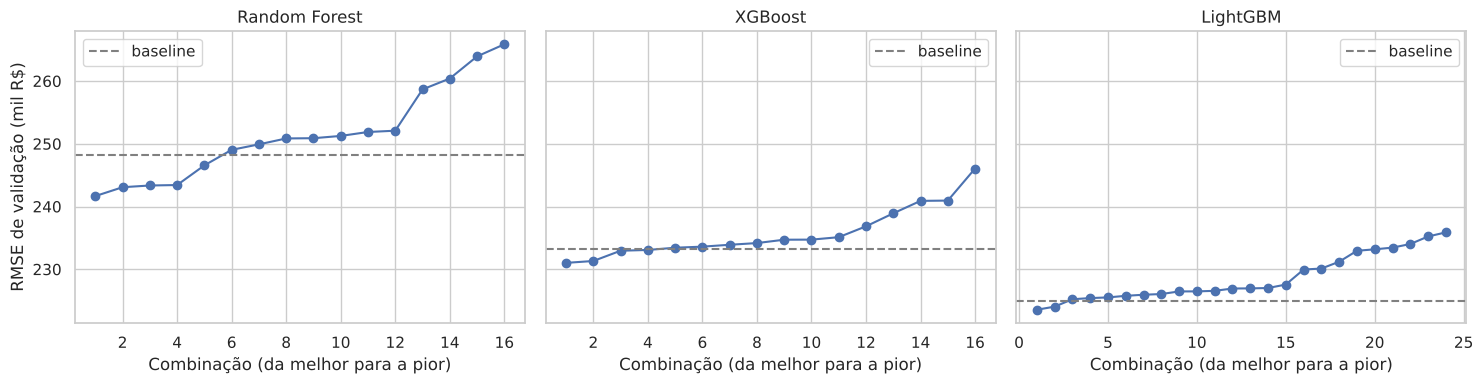

In [19]:
# RMSE de validação de todas as combinações testadas
fig, ax = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for i, (nome, busca) in enumerate(buscas_grid.items()):
    rmse = np.sort(-busca.cv_results_["mean_test_score"]) / 1000
    ax[i].plot(range(1, len(rmse) + 1), rmse, "o-")
    ax[i].axhline(baselines.set_index("Modelo").loc[nome, "RMSE_CV"] / 1000, ls="--", color="gray", label="baseline")
    ax[i].set_title(nome)
    ax[i].set_xlabel("Combinação (da melhor para a pior)")
    ax[i].legend()
ax[0].set_ylabel("RMSE de validação (mil R$)")
plt.tight_layout()
plt.show()

O Grid Search melhorou um pouco o Random Forest (de R\$ 248,3 mil para R\$ 241,7 mil) e o XGBoost (de R\$ 233,2 mil para R\$ 231,0 mil). No LightGBM a melhora foi pequena (de R\$ 224,9 mil para R\$ 223,6 mil). Em todos os casos o ganho foi menor que o desvio entre os folds, então os baselines já estavam perto do melhor que essas grades conseguem.

**Optuna.** Diferente do Grid Search, o Optuna não testa uma lista fixa: ele sorteia valores dentro de intervalos e, depois das primeiras tentativas, usa os resultados anteriores (método TPE) para decidir onde procurar. Usamos o `TPESampler` com a configuração padrão, em que os 10 primeiros trials são sorteados ao acaso; do 11º ao 20º a busca é guiada pelo que funcionou antes. Por isso fizemos 20 trials: com 10 ou menos, a busca inteira seria só sorteio.

A função objetivo de cada modelo recebe os valores sugeridos, monta o mesmo pipeline e devolve o RMSE médio nos mesmos 5 folds do Grid Search; o teste não participa da busca. Fizemos 20 trials por modelo, a quantidade de referência do enunciado (cada trial também treina 5 vezes). Nos modelos de boosting incluímos também a fração de anúncios usada por árvore (`subsample`), que não estava no Grid Search. Os parâmetros que não entram na busca ficam iguais aos do modelo inicial (por exemplo, `colsample_bytree=0.85`), como já acontecia no Grid Search. Para isso as funções objetivo usam a `modelo_com`, que parte do modelo inicial e troca só os parâmetros sugeridos; assim a configuração que o Optuna encontra é exatamente a que aparece depois na tabela final.

In [20]:
# faz uma cópia do modelo inicial e troca só os parâmetros indicados; assim a busca, a tabela
# final e o modelo salvo usam exatamente a mesma configuração
def modelo_com(nome, parametros):
    base = {"Random Forest": rf_base, "XGBoost": xgb_base, "LightGBM": lgbm_base}[nome]
    return clone(base).set_params(**parametros)


def rmse_cv(modelo):
    notas = cross_val_score(montar_pipeline(modelo), X_treino, y_treino, cv=cv,
                            scoring="neg_root_mean_squared_error")
    return -notas.mean()


def objetivo_rf(trial):
    return rmse_cv(modelo_com("Random Forest", {
        "n_estimators": trial.suggest_int("n_estimators", 100, 250, step=50),
        "max_depth": trial.suggest_categorical("max_depth", [None, 10, 16, 24]),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 8),
        "max_features": trial.suggest_float("max_features", 0.3, 1.0),
    }))


def objetivo_xgb(trial):
    return rmse_cv(modelo_com("XGBoost", {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1200, step=100),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 9),
        "min_child_weight": trial.suggest_float("min_child_weight", 1, 15),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
    }))


def objetivo_lgbm(trial):
    return rmse_cv(modelo_com("LightGBM", {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1200, step=100),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 8, 96),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 60),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
    }))


estudos = {}
linhas = []
for nome, objetivo in [("Random Forest", objetivo_rf), ("XGBoost", objetivo_xgb), ("LightGBM", objetivo_lgbm)]:
    # TPESampler padrão: os 10 primeiros trials são sorteados; a partir do 11º o TPE usa o histórico
    estudo = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))
    t0 = perf_counter()
    estudo.optimize(objetivo, n_trials=20)
    tempo = perf_counter() - t0
    estudos[nome] = estudo
    print(nome, "- melhores parâmetros:", {k: round(v, 4) if isinstance(v, float) else v for k, v in estudo.best_params.items()})
    linhas.append({"Modelo": nome, "Trials": 20, "RMSE_CV": estudo.best_value,
                   "Trial_do_melhor": estudo.best_trial.number + 1, "Tempo_s": tempo})

resultado_optuna = pd.DataFrame(linhas)
resultado_optuna.round(2)

Random Forest - melhores parâmetros: {'n_estimators': 150, 'max_depth': 24, 'min_samples_leaf': 1, 'max_features': 0.8081}


XGBoost - melhores parâmetros: {'n_estimators': 900, 'learning_rate': 0.0123, 'max_depth': 7, 'min_child_weight': 11.7446, 'subsample': 0.6827}


LightGBM - melhores parâmetros: {'n_estimators': 1200, 'learning_rate': 0.0245, 'num_leaves': 35, 'min_child_samples': 47, 'subsample': 0.838}


,Modelo,Trials,RMSE_CV,Trial_do_melhor,Tempo_s
0,Random Forest,20,239398.90,19,156.78
1,XGBoost,20,227800.75,14,83.41
2,LightGBM,20,221077.48,15,103.81


O gráfico mostra o melhor erro encontrado até cada trial, para ver como a busca evoluiu.

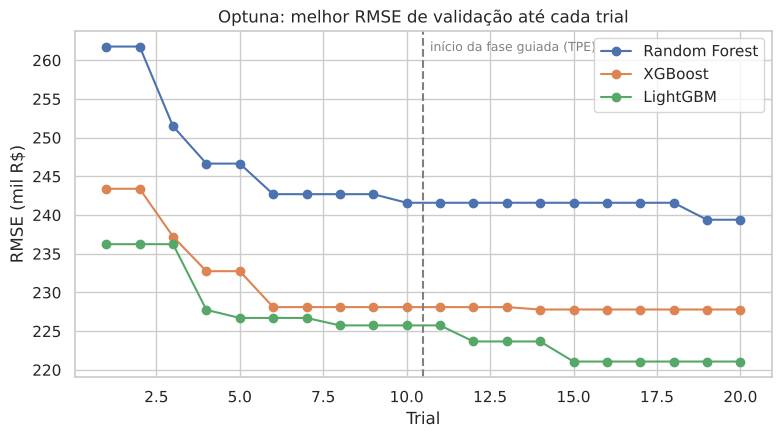

In [21]:
# melhor RMSE encontrado até cada trial (mesma lógica do gráfico da aula 20)
plt.figure(figsize=(9, 4.5))
for nome, estudo in estudos.items():
    melhor = np.inf
    melhores = []
    for t in estudo.trials:
        melhor = min(melhor, t.value)
        melhores.append(melhor / 1000)
    plt.plot(range(1, len(melhores) + 1), melhores, "o-", label=nome)
plt.axvline(10.5, ls="--", color="gray")
plt.text(10.7, plt.ylim()[1] * 0.995, "início da fase guiada (TPE)", va="top", fontsize=9, color="gray")
plt.title("Optuna: melhor RMSE de validação até cada trial")
plt.xlabel("Trial")
plt.ylabel("RMSE (mil R$)")
plt.legend()
plt.show()


A tabela junta as duas estratégias, com o tempo de cada busca e o desvio entre os folds.

In [22]:
# Grid Search x Optuna
comparacao = pd.DataFrame({
    "Modelo": resultado_grid["Modelo"],
    "RMSE_Grid": resultado_grid["RMSE_CV"],
    "RMSE_Optuna": resultado_optuna["RMSE_CV"],
    "Tempo_Grid_s": resultado_grid["Tempo_s"],
    "Tempo_Optuna_s": resultado_optuna["Tempo_s"],
    "Desvio_entre_folds": resultado_grid["RMSE_CV_dp"],
})
comparacao.round(2)

,Modelo,RMSE_Grid,RMSE_Optuna,Tempo_Grid_s,Tempo_Optuna_s,Desvio_entre_folds
0,Random Forest,241666.93,239398.90,107.11,156.78,28910.49
1,XGBoost,231022.26,227800.75,60.25,83.41,21472.14
2,LightGBM,223550.78,221077.48,128.86,103.81,23047.04


O Optuna encontrou erros um pouco menores que o Grid Search nos três modelos: no Random Forest, R\$ 239,4 mil contra R\$ 241,7 mil; no XGBoost, R\$ 227,8 mil contra R\$ 231,0 mil; e no LightGBM, R\$ 221,1 mil contra R\$ 223,6 mil. Ele testou valores que não estavam nas grades, como taxas de aprendizado mais baixas (0,012 no XGBoost e 0,024 no LightGBM) compensadas por mais árvores, e `min_child_samples` perto de 47 no LightGBM, que obriga cada folha a ter mais anúncios e deixa o modelo menos preso ao treino.

Mesmo assim, todas essas diferenças são menores que o desvio entre os folds (entre R\$ 21 mil e R\$ 29 mil), então na prática as duas estratégias chegaram ao mesmo nível. Na estabilidade o Optuna levou vantagem: na tabela da seção 6, as configurações dele variaram menos entre os folds no XGBoost (desvio de R\$ 15,7 mil contra R\$ 21,5 mil) e no LightGBM (R\$ 17,9 mil contra R\$ 23,0 mil). No tempo, o Optuna foi mais demorado no Random Forest e no XGBoost e mais rápido no LightGBM; no Grid Search o custo cresce a cada valor que entra na grade, enquanto no Optuna ele é fixado pelo número de trials. Pelo gráfico, o melhor resultado de cada modelo apareceu entre o trial 14 e o 19, ou seja, na fase guiada pelo TPE, depois dos 10 sorteios iniciais. Isso mostra que o TPE realmente ajudou a encontrar configurações melhores, e com mais trials a busca talvez ainda melhorasse um pouco.


---

## 6. Escolha do modelo final

Para comparar tudo do mesmo jeito, avaliamos as nove configurações (modelo inicial, melhor do Grid Search e melhor do Optuna, para cada algoritmo) com a mesma validação cruzada.

In [23]:
# tabela com as nove configurações (mesmos folds)
# modelo_com foi definida na seção 5, junto com as funções do Optuna
configuracoes = {}
for nome in ["Random Forest", "XGBoost", "LightGBM"]:
    configuracoes[(nome, "Baseline")] = modelo_com(nome, {})
    configuracoes[(nome, "Grid Search")] = modelo_com(nome, {k.replace("regressor__modelo__", ""): v
                                                             for k, v in buscas_grid[nome].best_params_.items()})
    configuracoes[(nome, "Optuna")] = modelo_com(nome, estudos[nome].best_params)

linhas = []
for (nome, busca), modelo in configuracoes.items():
    linha = avaliar(nome, modelo)
    linha["Configuração"] = busca
    linhas.append(linha)

final = pd.DataFrame(linhas)
final["Gap_R$"] = final["RMSE_CV"] - final["RMSE_treino"]
final["Gap_%"] = 100 * (final["RMSE_CV"] - final["RMSE_treino"]) / final["RMSE_treino"]
final = final[["Modelo", "Configuração", "RMSE_treino", "RMSE_CV", "RMSE_CV_dp", "Gap_R$", "Gap_%", "MAE_CV", "R2_CV", "Tempo_s"]]
final = final.sort_values("RMSE_CV").reset_index(drop=True)
final.round(2)

,Modelo,Configuração,RMSE_treino,RMSE_CV,RMSE_CV_dp,Gap_R$,Gap_%,MAE_CV,R2_CV,Tempo_s
0,LightGBM,Optuna,138846.53,221077.48,17941.30,82230.95,59.22,95450.44,0.91,8.07
1,LightGBM,Grid Search,112691.47,223550.78,23047.04,110859.31,98.37,96564.33,0.91,2.52
2,LightGBM,Baseline,106277.66,224897.62,22037.79,118619.96,111.61,96960.32,0.91,3.17
3,XGBoost,Optuna,138162.59,227800.75,15709.76,89638.16,64.88,98569.53,0.91,5.68
4,XGBoost,Grid Search,87793.01,231022.26,21472.14,143229.25,163.14,97605.04,0.90,3.14
5,XGBoost,Baseline,101998.39,233164.80,24843.35,131166.41,128.60,98503.68,0.90,2.58
6,Random Forest,Optuna,94495.75,239398.90,29402.39,144903.14,153.34,102957.20,0.89,9.14
7,Random Forest,Grid Search,95023.40,241666.93,28910.49,146643.53,154.32,102684.49,0.89,12.01
8,Random Forest,Baseline,132543.88,248273.05,32248.09,115729.17,87.31,105205.78,0.89,8.11


In [24]:
escolha = (final.loc[0, "Modelo"], final.loc[0, "Configuração"])
print("Configuração escolhida:", escolha)

Configuração escolhida: ('LightGBM', 'Optuna')


O LightGBM do Optuna teve o menor erro de validação (R\$ 221,1 mil) e foi o escolhido. O LightGBM ficou à frente em todas as etapas: no modelo inicial, no Grid Search e no Optuna. Nenhuma diferença entre os algoritmos passou de um desvio-padrão entre os folds, então não dá para dizer que um é muito melhor que o outro; o que sustenta a escolha é essa consistência.

Entre as três versões do LightGBM a diferença foi de menos de R\$ 4 mil. Além de errar menos na validação, a versão do Optuna tem o menor gap entre treino e validação entre as três (R\$ 82 mil, ou 59%, contra R\$ 111 mil e 98% da versão do Grid Search) e o menor desvio entre os folds (R\$ 17,9 mil). Ou seja, ela decora menos o treino e varia menos de uma parte da base para outra. O custo é um treino mais lento (1.200 árvores contra 400), o que não atrapalha o app, porque o modelo é treinado uma vez só. O Random Forest ficou atrás em todas as versões.


A curva de aprendizado treina o modelo escolhido com quantidades crescentes de anúncios e mede o erro no treino e na validação. Se as duas curvas ficam altas e juntas, o modelo é simples demais (underfitting); se o treino fica bem abaixo da validação, ele se ajusta demais ao treino (overfitting).

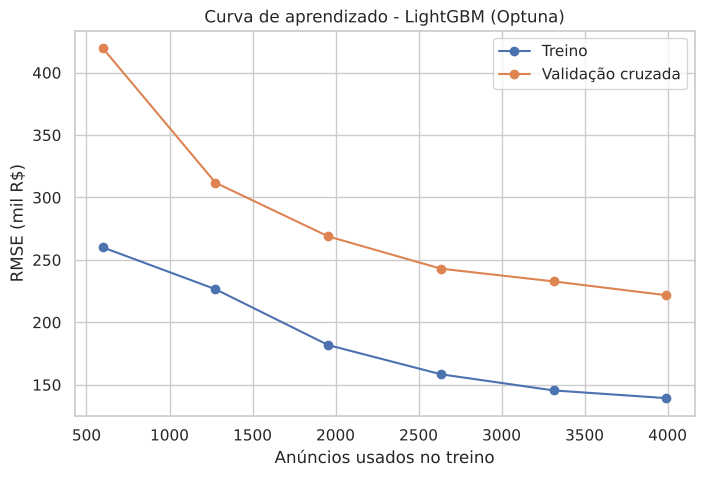

,Anúncios,RMSE_treino,RMSE_validacao
0,598,260048.0,419615.0
1,1277,226533.0,311827.0
2,1956,181808.0,268850.0
3,2635,158393.0,242980.0
4,3314,145463.0,232784.0
5,3993,139293.0,221716.0


In [25]:
# curva de aprendizado da configuração escolhida
tamanhos, treino, validacao = learning_curve(montar_pipeline(configuracoes[escolha]), X_treino, y_treino,
                                             cv=cv, train_sizes=np.linspace(0.15, 1.0, 6),
                                             scoring="neg_root_mean_squared_error")
plt.figure(figsize=(8, 5))
plt.plot(tamanhos, -treino.mean(axis=1) / 1000, "o-", label="Treino")
plt.plot(tamanhos, -validacao.mean(axis=1) / 1000, "o-", label="Validação cruzada")
plt.title(f"Curva de aprendizado - {escolha[0]} ({escolha[1]})")
plt.xlabel("Anúncios usados no treino")
plt.ylabel("RMSE (mil R$)")
plt.legend()
plt.show()

pd.DataFrame({"Anúncios": tamanhos, "RMSE_treino": -treino.mean(axis=1),
              "RMSE_validacao": -validacao.mean(axis=1)}).round(0)

Com poucos anúncios (cerca de 600) o erro de validação é alto, R\$ 420 mil. Ele cai rápido até uns 2.000 anúncios e continua caindo até R\$ 222 mil com o treino completo. O erro de treino fica abaixo do de validação em todos os tamanhos e termina em R\$ 139 mil.

A distância entre as duas curvas mostra algum overfitting, mas ela diminui com mais dados: de R\$ 160 mil com 600 anúncios para R\$ 82 mil com o treino completo. As curvas não estão juntas em um erro alto, então não há underfitting. Como a curva de validação ainda está descendo, mais anúncios ajudariam o modelo.


Para ver quais variáveis o modelo mais usa, treinamos o modelo escolhido com o treino e mostramos as 15 de maior importância.

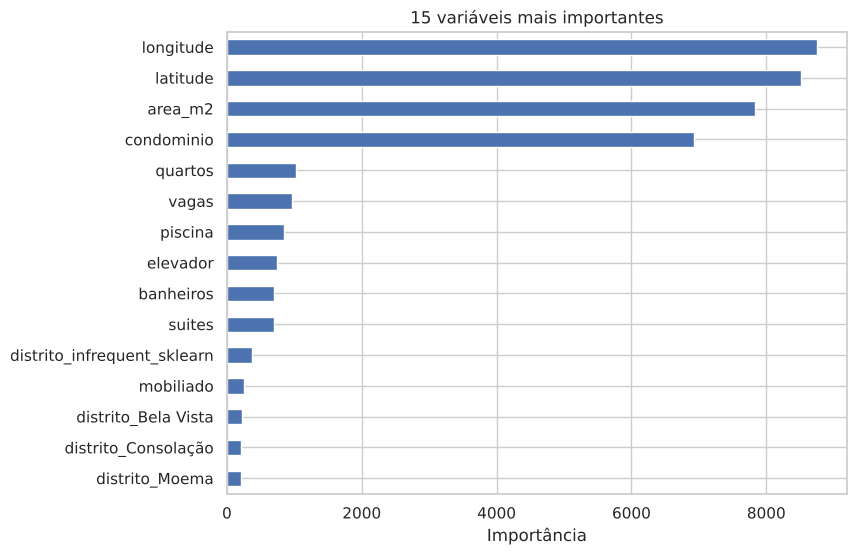

In [26]:
# importância das variáveis (modelo treinado no treino)
pipe = montar_pipeline(configuracoes[escolha]).fit(X_treino, y_treino)
nomes = pipe.regressor_.named_steps["preparo"].get_feature_names_out()
nomes = [n.replace("num__", "").replace("cat__", "") for n in nomes]
importancia = pd.Series(pipe.regressor_.named_steps["modelo"].feature_importances_, index=nomes)

importancia.sort_values().tail(15).plot(kind="barh", figsize=(8, 6))
plt.title("15 variáveis mais importantes")
plt.xlabel("Importância")
plt.show()

As variáveis mais usadas pelo modelo são longitude, latitude, área e condomínio, muito à frente das outras. Quartos tem importância baixa mesmo tendo correlação de 0,54 com o preço, porque a informação dos quartos já está quase toda na área (correlação de 0,74 entre as duas), e o modelo prefere a área, que separa melhor os preços. Os distritos aparecem pouco porque cada um virou uma coluna 0/1 separada e a importância fica dividida entre muitas colunas; além disso, as coordenadas já dão a localização com mais detalhe.

Essa importância conta quantas vezes o modelo usou a variável para dividir os dados. Ela não diz se a variável aumenta ou diminui o preço, e variáveis com muitos valores diferentes, como coordenadas e área, costumam aparecer mais.

Por último, comparamos o preço real com o previsto. Usamos as previsões da validação cruzada (cada anúncio é previsto por um modelo que não o viu no treino), assim o teste continua guardado.

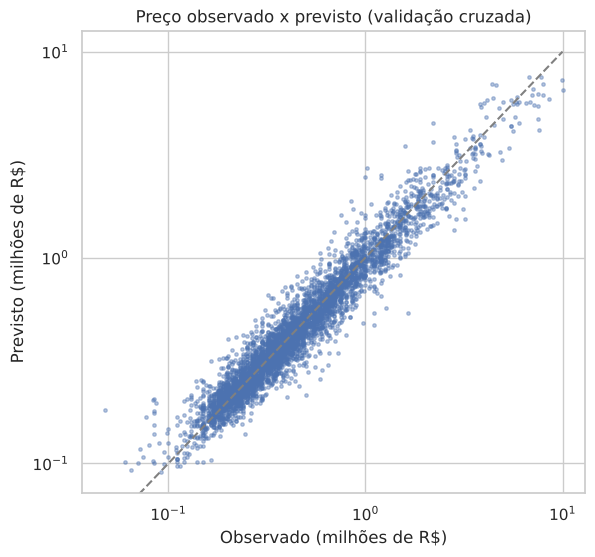

Erro percentual médio: 14.0 %
Metade dos imóveis tem erro abaixo de: 10.1 %


In [27]:
# previsto x observado, usando validação cruzada (o teste continua guardado)
previsto = cross_val_predict(montar_pipeline(configuracoes[escolha]), X_treino, y_treino, cv=cv)

plt.figure(figsize=(6.5, 6))
plt.scatter(y_treino / 1e6, previsto / 1e6, s=6, alpha=0.4)
plt.plot([0, 10], [0, 10], "--", color="gray")
plt.xscale("log")
plt.yscale("log")
plt.title("Preço observado x previsto (validação cruzada)")
plt.xlabel("Observado (milhões de R$)")
plt.ylabel("Previsto (milhões de R$)")
plt.show()

erro_pct = (100 * (y_treino - previsto).abs() / y_treino)
print("Erro percentual médio:", round(erro_pct.mean(), 1), "%")
print("Metade dos imóveis tem erro abaixo de:", round(erro_pct.median(), 1), "%")

Os pontos ficam em volta da linha de previsão perfeita em toda a faixa de preço, sem o modelo errar sempre para cima ou sempre para baixo. O erro médio é de 14% do valor do imóvel, e metade dos anúncios tem erro abaixo de 10%. Como treinamos com o log do preço, o erro fica parecido em porcentagem para imóveis baratos e caros. Para ter uma referência de preço, é um bom resultado; para avaliar um imóvel específico, não seria suficiente.

---

## 7. Teste final e aplicação

Só agora usamos o conjunto de teste. O modelo escolhido é treinado com todo o treino e avaliado uma única vez no teste. Usar o teste uma vez só garante que ele represente dados novos; se tomássemos decisões olhando para ele, o resultado final ficaria otimista.

In [28]:
modelo_final = montar_pipeline(configuracoes[escolha]).fit(X_treino, y_treino)
previsto_teste = modelo_final.predict(X_teste)

linha_cv = final.loc[0]
# RMSE de cada fold do modelo escolhido, para comparar com o teste
folds = -cross_val_score(montar_pipeline(configuracoes[escolha]), X_treino, y_treino, cv=cv,
                         scoring="neg_root_mean_squared_error")
print("RMSE de cada fold da validação cruzada:", (folds / 1000).round(1), "mil R$")

pd.DataFrame({
    "Validação cruzada": [linha_cv["RMSE_CV"], linha_cv["MAE_CV"], linha_cv["R2_CV"]],
    "Teste": [root_mean_squared_error(y_teste, previsto_teste), mean_absolute_error(y_teste, previsto_teste),
              r2_score(y_teste, previsto_teste)],
}, index=["RMSE", "MAE", "R²"]).round(3)

RMSE de cada fold da validação cruzada: [202.7 227.3 199.9 248.5 227. ] mil R$


,Validação cruzada,Teste
RMSE,221077.483,197908.606
MAE,95450.441,87993.567
R²,0.911,0.934


No teste, o RMSE foi de R\$ 197,9 mil, o MAE de R\$ 88,0 mil e o R² de 0,93. O resultado ficou melhor que a média da validação cruzada (RMSE de R\$ 221,1 mil). Nos cinco folds o RMSE variou entre R\$ 199,9 mil e R\$ 248,5 mil, então o teste ficou um pouco abaixo até do melhor fold. Isso indica que o sorteio do teste caiu com um pouco menos de imóveis difíceis do que a média; com outra divisão o número seria um pouco diferente.

Como o teste não foi usado para escolher nada, essa diferença não vem de vazamento. O resultado é compatível com o que a validação cruzada e a curva de aprendizado mostraram: o modelo generaliza bem para anúncios que ele não viu, e o número mais seguro para esperar em dados novos é o da validação cruzada, perto de R\$ 220 mil de RMSE.


No teste de consistência olhamos anúncios individuais do teste: o de menor erro, o de maior erro e quatro sorteados com semente fixa, para não mostrar só casos favoráveis.

In [29]:
# teste de consistência com anúncios do teste
casos = X_teste.copy()
casos["preco_real"] = y_teste
casos["preco_previsto"] = previsto_teste.round(0)
casos["erro"] = casos["preco_real"] - casos["preco_previsto"]
casos["erro_%"] = (100 * casos["erro"] / casos["preco_real"]).round(1)

exemplos = pd.concat([
    casos.loc[[casos["erro_%"].abs().idxmin()]],                     # melhor acerto
    casos.loc[[casos["erro_%"].abs().idxmax()]],                     # caso mais difícil
    casos.drop(index=[casos["erro_%"].abs().idxmin(), casos["erro_%"].abs().idxmax()]).sample(4, random_state=SEED),
])
exemplos[["distrito", "area_m2", "quartos", "banheiros", "vagas", "condominio", "preco_real", "preco_previsto", "erro", "erro_%"]]

,distrito,area_m2,quartos,banheiros,vagas,condominio,preco_real,preco_previsto,erro,erro_%
1893,Ipiranga,133,3,4,2,900.0,1245000,1245171.0,-171.0,-0.0
1894,Ipiranga,110,3,2,2,1500.0,450000,861744.0,-411744.0,-91.5
1902,Ipiranga,72,3,2,1,550.0,550000,501796.0,48204.0,8.8
1832,Cursino,49,2,2,1,404.0,219000,238212.0,-19212.0,-8.8
947,Carrão,60,2,2,1,NaN,385000,381623.0,3377.0,0.9
4894,Jaçanã,67,3,2,1,300.0,315000,354120.0,-39120.0,-12.4


O melhor acerto foi um apartamento de 133 m² no Ipiranga: R\$ 1.245.000 anunciado e R\$ 1.245.171 previsto. Nos quatro anúncios sorteados o erro ficou entre 0,9% e 12,4%.

O caso mais difícil é um apartamento de 110 m² no Ipiranga, com 3 quartos, 2 vagas e condomínio de R\$ 1.500, anunciado por R\$ 450 mil. O modelo previu R\$ 862 mil. Pelas características, principalmente o condomínio alto, o preço anunciado parece baixo; pode ser erro no anúncio ou algo que a base não mostra, como o estado do imóvel. O modelo seguiu o padrão que aprendeu, e esse caso mostra o limite de prever só com as informações do anúncio.


Salvamos o modelo final e as informações que o app precisa (distritos, faixas de valores, métricas e o anúncio do teste de paridade). O arquivo do modelo guarda o pipeline inteiro: preenchimento dos vazios, distritos em colunas, modelo e log do preço.

In [30]:
# salva o modelo e as informações que o app precisa
os.makedirs("modelo", exist_ok=True)
joblib.dump(modelo_final, "modelo/modelo_final.joblib")

exemplo_paridade = exemplos.iloc[2]
entrada = {}
for coluna in colunas_x:
    valor = exemplo_paridade[coluna]
    if pd.isna(valor):
        valor = None             # valor faltando fica vazio no JSON
    elif hasattr(valor, "item"):
        valor = valor.item()     # número do numpy vira número comum do Python (o JSON não aceita numpy)
    entrada[coluna] = valor
info = {
    "modelo": f"{escolha[0]} ({escolha[1]})",
    "rmse_teste": root_mean_squared_error(y_teste, previsto_teste),
    "mae_teste": mean_absolute_error(y_teste, previsto_teste),
    "r2_teste": r2_score(y_teste, previsto_teste),
    "distritos": sorted(X_treino["distrito"].unique().tolist()),
    "faixas": {c: [float(X_treino[c].min()), float(X_treino[c].max())] for c in ["area_m2", "quartos", "banheiros", "vagas", "condominio"]},
    "paridade_entrada": entrada,
    "paridade_previsao_notebook": float(modelo_final.predict(pd.DataFrame([entrada]).astype({c: "float" for c in colunas_numericas}))[0]),
}
with open("modelo/info.json", "w", encoding="utf-8") as f:
    json.dump(info, f, ensure_ascii=False, indent=2)
venda.to_csv("base_tratada.csv", index=False)

print("Anúncio usado no teste de paridade:", entrada)
print("Previsão do notebook: R$", round(info["paridade_previsao_notebook"], 2))

Anúncio usado no teste de paridade: {'area_m2': 72, 'quartos': 3, 'banheiros': 2, 'suites': 1, 'vagas': 1, 'condominio': 550.0, 'elevador': 1, 'mobiliado': 0, 'piscina': 1, 'novo': 0, 'latitude': -23.596728, 'longitude': -46.604326, 'distrito': 'Ipiranga'}
Previsão do notebook: R$ 501796.37


No app, o botão "Usar o anúncio do teste de paridade" preenche o formulário com esse mesmo anúncio, e a previsão mostrada tem que ser igual à do notebook. Isso acontece porque o app carrega o mesmo arquivo `modelo_final.joblib` e aplica antes a mesma função `limpar_imovel`.

No formulário, o usuário escolhe o distrito e o app usa como localização o centro típico desse distrito (a mediana das coordenadas dos anúncios da base); quem souber a latitude e a longitude exatas pode informar. Se o usuário não souber o condomínio, coloca 0; a função transforma em vazio e o pipeline preenche com a mediana do treino, como aconteceu no notebook. Se digitar um valor fora do que existe na base, o app avisa que a previsão pode ser pouco confiável.

### Síntese da solução

**Problema, base e alvo.** Prever o preço de venda anunciado de apartamentos em São Paulo (regressão), com a mesma base do CP04: anúncios de abril de 2019, 6.240 depois do tratamento.

**Data wrangling e variáveis.** Além das duplicatas, encontramos problemas que não tínhamos visto no CP04: condomínio e coordenadas zerados (tratados como informação faltando), o "distrito" Medeiros com coordenadas em Jundiaí, anúncios com mais suítes que quartos e 10 preços incoerentes para o distrito. Usamos 13 variáveis; o preço por m² ficou de fora por vazamento. Imputação e codificação ficam dentro do pipeline, e o modelo aprende o log do preço porque ele é muito assimétrico.

**Comparação dos modelos.** Nos baselines, o LightGBM teve o menor erro (R\$ 224,9 mil), seguido do XGBoost (R\$ 233,2 mil) e do Random Forest (R\$ 248,3 mil).

**Grid Search e Optuna.** O Optuna ficou um pouco à frente nos três modelos e com menos variação entre os folds, mas as diferenças para o Grid Search foram menores que a variação entre os folds. O modelo final é o LightGBM do Optuna, que teve o menor erro de validação (R\$ 221,1 mil) e o menor gap entre treino e validação entre as versões do LightGBM.

**Overfitting e underfitting.** O erro de validação é maior que o de treino (gap de R\$ 82 mil), então há algum overfitting, mas a curva de aprendizado mostra essa distância diminuindo com mais dados. Não há underfitting (R² de validação de 0,91).

**Teste final.** RMSE de R\$ 197,9 mil, MAE de R\$ 88,0 mil e R² de 0,93, um pouco melhor que a validação cruzada e perto do melhor fold. O erro médio fica em torno de 14% do valor do imóvel.

**Streamlit e paridade.** O app carrega o mesmo `modelo_final.joblib` e usa a mesma função `limpar_imovel`. O anúncio de paridade (72 m² no Ipiranga) dá R\$ 501.796,37 no notebook e deve dar o mesmo valor no app.


Links do repositório e do app publicado:

In [31]:
URL_GITHUB = "https://github.com/RafaellSantiagoMS/DataScience_CP05/"
URL_STREAMLIT = "https://datasciencecp05-tnjy9hyxbr6y7vqhhibo4p.streamlit.app/"

print("GitHub:", URL_GITHUB)
print("Streamlit:", URL_STREAMLIT)

GitHub: https://github.com/RafaellSantiagoMS/DataScience_CP05/
Streamlit: https://datasciencecp05-tnjy9hyxbr6y7vqhhibo4p.streamlit.app/


---

## Referências

* BREIMAN, Leo. Random Forests. *Machine Learning*, v. 45, p. 5–32, 2001.

* CHEN, Tianqi; GUESTRIN, Carlos. XGBoost: A Scalable Tree Boosting System. In: *Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining*, 2016.

* KE, Guolin et al. LightGBM: A Highly Efficient Gradient Boosting Decision Tree. In: *Advances in Neural Information Processing Systems*, 2017.

* AKIBA, Takuya et al. Optuna: A Next-generation Hyperparameter Optimization Framework. In: *Proceedings of the 25th ACM SIGKDD International Conference on Knowledge Discovery and Data Mining*, 2019.

* GÉRON, Aurélien. *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow*. 3. ed. Sebastopol: O'Reilly Media, 2023.

* KUHN, Max; JOHNSON, Kjell. *Feature Engineering and Selection: A Practical Approach for Predictive Models*. Boca Raton: CRC Press, 2020.